In [1]:
import shutil
import os
import sys
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
# import tensorflow_datasets as tfds
import h5py
import torch
import tqdm
import numpy as np
import time
import glob
from math import sqrt
from matplotlib import pyplot as plt

In [2]:
def cal_cmd_vel(cmd_eef_pos, delta = 3):
    diff = cmd_eef_pos[delta:] - cmd_eef_pos[:-delta]
    return np.sqrt(np.sum(diff*diff, axis=1)).mean()

def cal_cmd_state_diff(cmd_eef_pos, state_eef_pos):
    diff = cmd_eef_pos - state_eef_pos
    return np.sqrt(np.sum(diff*diff, axis=1)).mean()

In [8]:
person = 'LJ'
datapaths = [
                # '/mnt/pfs-chihiro/20250306',
                # '/mnt/pfs-chihiro/20250307',
                # '/mnt/pfs-chihiro/20250308',
                # '/mnt/pfs-chihiro/20250310',
                '/mnt/pfs-chihiro/20250311',
                '/mnt/pfs-chihiro/20250312',
                # '/mnt/pfs-chihiro/20250313',
                # '/mnt/pfs-chihiro/20250314',
                # '/mnt/pfs-chihiro/20250315',
                # '/mnt/pfs-chihiro/20250317',
                # '/mnt/pfs-chihiro/20250318',
]
# mission = '01FULL_HF'
mission = 'QUICK'


In [17]:
# dataset_files = []
# for dataset_path in datapaths:
#     dataset_files += [os.path.join(dataset_path, p) for p in os.listdir(dataset_path) if (person in p and mission in p)]

dataset_files = ['/mnt/pfs-chihiro/20250506/20250506_Y_M105_DYFV2_STEP0to1_HF_GY']
dataset_files = ['/mnt/pfs-chihiro/20250509/20250509_Y_M104_MULTI_PICKPLACE_PutPlateOnRack_LYB']
stats = {'len':[], 'cmd_vel':[], 'cmd_state_diff':[]}
for h5_path in dataset_files:
    hdf5_file_names = glob.glob(os.path.join(h5_path,'*.hdf5'))
    for hdf5_file_name in tqdm.tqdm(hdf5_file_names):
        h5_file = h5py.File(hdf5_file_name,'r')
        ep = {k:np.array(v) for k,v in h5_file.items()}
        h5_file.close()
        
        stats['len'].append(ep['robot0_eef_pos'].shape[0])
        cmd_vel = (cal_cmd_vel(ep['robot0_cmd_eef_pos']) + cal_cmd_vel(ep['robot1_cmd_eef_pos']))/2
        stats['cmd_vel'].append(cmd_vel)
        cmd_state_diff = (cal_cmd_state_diff(ep['robot0_cmd_eef_pos'], ep['robot0_eef_pos']) + 
                          cal_cmd_state_diff(ep['robot1_cmd_eef_pos'], ep['robot1_eef_pos']))/2
        stats['cmd_state_diff'].append(cmd_state_diff)

100%|██████████| 111/111 [01:21<00:00,  1.37it/s]


In [11]:
LTJ_stats = {k:np.array(v) for k,v in stats.items()}
LTJ_stats['cmd_vel'] = np.nan_to_num(LTJ_stats['cmd_vel'], nan=0)
print(LTJ_stats['len'].mean(), LTJ_stats['cmd_vel'].mean()*100, LTJ_stats['cmd_state_diff'].mean()*100)

732.047619047619 1.8471541821819464 4.096450225417531


In [12]:
WW_stats = {k:np.array(v) for k,v in stats.items()}
WW_stats['cmd_vel'] = np.nan_to_num(WW_stats['cmd_vel'], nan=0)
print(WW_stats['len'].mean(), WW_stats['cmd_vel'].mean()*100, WW_stats['cmd_state_diff'].mean()*100)

732.047619047619 1.8471541821819464 4.096450225417531


In [13]:
WHJ_stats = {k:np.array(v) for k,v in stats.items()}
WHJ_stats['cmd_vel'] = np.nan_to_num(WHJ_stats['cmd_vel'], nan=0)
print(WHJ_stats['len'].mean(), WHJ_stats['cmd_vel'].mean()*100, WHJ_stats['cmd_state_diff'].mean()*100)

732.047619047619 1.8471541821819464 4.096450225417531


In [14]:
# 01FULL:
540.184375 1.5836817739552236 1.2352673762587456 LTJ
547.596 2.026993309712263 1.3055635018067329 WW
658.5813953488372 2.1277687988182152 1.034181737937435 WHJ
542.9243697478992 2.4095494553841497 1.6220656764659982 GY
423.9474835886214 2.32668148990611 1.8547732562473669 LJ
576.2321755027423 1.8712744577388145 1.2054597370946096 GZQ

# 15QUICK:
1681.741935483871 1.1485287221484533 0.8118516881422249 WHJ 
1740.2863849765258 1.1173638447983816 1.100564652226307 LJ


SyntaxError: invalid syntax (1119072037.py, line 2)

In [2]:
import os
import cv2
import numpy as np
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
import ffmpeg
import ipdb
import torch
import tqdm
import matplotlib.pyplot as plt
# import seaborn as sns
import matplotlib.patches as patches
from random import sample 
!export XDG_CACHE_HOME=/pfstem/likaiyu/resources/.cache
def plot_robot_xyplane_stats(action_points, state_points, save_name):
    points_np = action_points.numpy()[...,:2]
    points_np2 = state_points.numpy()[...,:2]
    # Plot
    plt.figure(figsize=(8, 6))
    # fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    plt.scatter(points_np[:, 0], points_np[:, 1],
                s=2,               # dot size
                c='red',          # dot color
                alpha=.1)        # transparency to emphasize density
    plt.scatter(points_np2[:, 0], points_np2[:, 1],
                s=2,               # dot size
                c='blue',          # dot color
                alpha=.1)        # transparency to emphasize density
    # patches.Rectangle((-0.6,))
    plt.axis([-0.6,0.6,-1.295,-0.095])
    plt.title('Robot EEF on XY plane')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    legend = plt.legend(['action','state'])
    for handle in legend.legend_handles:
        handle.set_alpha(1)
    plt.savefig(f'/root/PI_Official/data/visualization/XYPlane/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_singledim_stats(action_points, state_points, save_name):
    points_np = action_points.numpy()
    points_np2 = state_points.numpy()
    data = np.concatenate([points_np2[::2], points_np2[1::2]],1)
    # points = np.concatenate([points_np, points_np2], axis = 0)
    # data = points.T
    print(f'data shape {data.shape}')

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, patch_artist=True)
    plt.title("Boxplot of Each EEF Dimension")
    plt.ylabel("EEF Value")
    plt.xticks(range(1, 7), ['L_X','L_Y','L_Z','R_X','R_Y','R_Z'])  # label x-axis from Dim 0 to Dim 13
    plt.grid(True)
    plt.tight_layout()
    os.makedirs('/root/PI_Official/data/visualization/XYZ_BoxPlot', exist_ok = True)
    plt.savefig(f'/root/PI_Official/data/visualization/XYZ_BoxPlot/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def cal_cmd_vel(state_points, delta = 3):
    state_points = state_points.numpy()
    left_points = state_points[::2]
    right_points = state_points[1::2]
    diff = left_points[delta:] - left_points[:-delta]
    print(diff.mean())
    left_mean = np.sqrt(np.sum(diff*diff, axis=1)).mean()
    diff = right_points[delta:] - right_points[:-delta]
    print(diff.mean())
    right_mean = np.sqrt(np.sum(diff*diff, axis=1)).mean()
    return (left_mean + right_mean)/2

def cal_cmd_state_diff(action_points, state_points):
    action_points = action_points.numpy()
    state_points = state_points.numpy()
    diff = action_points - state_points
    return np.sqrt(np.sum(diff*diff, axis=1))

def find_outliers(data):
    from scipy.stats import zscore
    z_scores = zscore(data)
    threshold = 3
    outlier_indices = np.where(np.abs(z_scores) > threshold)[0]
    return outlier_indices

In [ ]:
!export XDG_CACHE_HOME=/pfstem/likaiyu/resources/.cache
repo_id='HRPI_MultiTask_PutPlateOnRack_0423_29'
sample_num = 20_000

dataset = LeRobotDataset(repo_id, local_files_only=True)
action_points = []
state_points = []
for i in tqdm.tqdm(sample(range(len(dataset)),sample_num)):

    item = dataset[i]
    action_points.append(item['actions'][:3])
    action_points.append(item['actions'][7:10])
    state_points.append(item['observation.state'][:3])
    state_points.append(item['observation.state'][7:10])

action_points = torch.stack(action_points)
state_points = torch.stack(state_points)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/HRPI_MultiTask_PutPlateOnRack_0423_29` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/HRPI_MultiTask_PutPlateOnRack_0423_29` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/4738 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/921 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [02:08<00:00, 155.64it/s]


data shape (20000, 6)


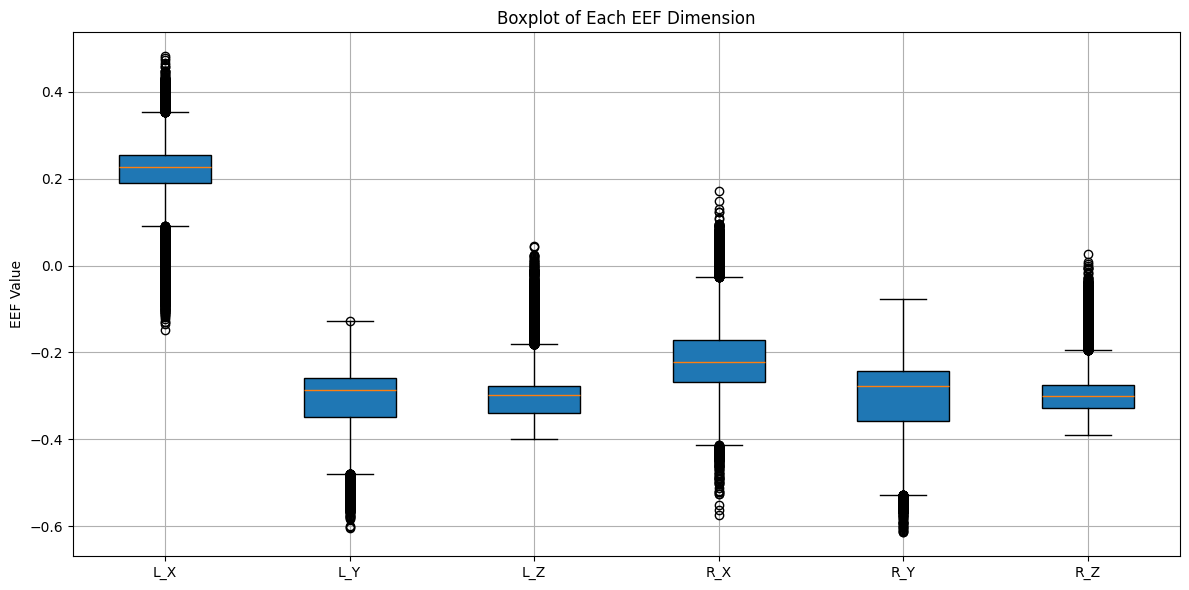

In [6]:
# plot_robot_xyplane_stats(action_points, state_points, repo_id)
plot_singledim_stats(action_points, state_points, repo_id)

In [33]:
cmd_state_diff = cal_cmd_state_diff(action_points, state_points)

# inds = find_outliers(cmd_state_diff)
inds = cmd_state_diff > 0.01
print(f'command state average difference is {cmd_state_diff.mean()}m')
print(f'{inds.sum()*50/sample_num}% points has cmd-state diff larger than 0.01m')
print(f'max cmd-state diff is {cmd_state_diff.max()}m')
# plot_robot_xyplane_stats(action_points[inds], state_points[inds], repo_id + '_outliers')

command state average difference is 0.000733406632207334m
1.5725% points has cmd-state diff larger than 0.01m
max cmd-state diff is 0.043169282376766205m


In [29]:
import os
import cv2
import numpy as np
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
import ffmpeg
import ipdb
import torch
import tqdm
import matplotlib.pyplot as plt
# import seaborn as sns
import matplotlib.patches as patches
from random import sample 

def plot_variant_comparison(action_points, state_points, title="Left Arm", save_name=None):
    """
    Plot comparison of two time-series variants over 7 dimensions.
    
    Args:
        action_points (np.ndarray): Shape (t, 7), first variant.
        state_points (np.ndarray): Shape (t, 7), second variant.
        title (str): Overall title of the plot.
        save_name (str or None): If provided, saves the figure to this path.
    """
    assert action_points.shape == state_points.shape, "Variants must have the same shape"
    assert action_points.shape[1] == 7, "Each variant must have 7 dimensions"
    axis_names = ['X','Y','Z','r','p','y','G']
    max_frame = 900
    action_points = action_points[:max_frame]
    state_points = state_points[:max_frame]

    t = action_points.shape[0]
    time = np.arange(t)/30

    fig, axes = plt.subplots(7, 1, figsize=(10, 12), sharex=True, dpi = 300)
    fig.suptitle(title, fontsize=14)

    for i in range(7):
        axes[i].plot(time, action_points[:, i], 'b--o', markersize=2,
               markerfacecolor='blue', markeredgecolor='black', markeredgewidth=0.5,
               label='action', alpha=0.6)
        axes[i].plot(time, state_points[:, i], 'r--o', markersize=2,
               markerfacecolor='red', markeredgecolor='black', markeredgewidth=0.5,
               label='state', alpha=0.6)
        axes[i].set_ylabel(axis_names[i])
        axes[i].grid(True)
        if i == 0:
            axes[i].legend(loc='upper right')

    axes[-1].set_xlabel('Time Step(s)')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    if save_name:
        plt.savefig(f'/root/PI_Official/data/visualization/episode_demo/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def preprocess_rotvec(points):
    assert points.shape[0] > 1
    rot_vec = points[...,3:6]
    rot_vec = rot_vec.numpy()
    for i in range(1, points.shape[0]):
        if np.dot(rot_vec[i], rot_vec[i-1]) < 0:
            rot_vec[i] *= -1
            print(f'norm is {np.sqrt(np.sum(rot_vec[i]**2))}')
    points[..., 3:6] = torch.tensor(rot_vec)
    return points

In [2]:
#visualize by episode
repo_id='YC_MeetingRoom_PutPenInBox_0514'
# repo_id = 'MultiTask_7task_0422'
# repo_id = 'HRPI_MultiTask_PutPlateOnRack_0423_29'
dataset = LeRobotDataset(repo_id, episodes = list(range(100)),local_files_only=True)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MeetingRoom_PutPenInBox_0514` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MeetingRoom_PutPenInBox_0514` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/31 [00:00<?, ?it/s]

In [28]:
episode_id = 5
start,end = dataset.episode_data_index['from'][episode_id], dataset.episode_data_index['to'][episode_id]

l_action_points, r_action_points = [],[]
l_state_points, r_state_points = [],[]
for i in tqdm.tqdm(range(start,end)):
    item = dataset[i]
    l_action_points.append(item['actions'][:7])
    r_action_points.append(item['actions'][7:])
    l_state_points.append(item['observation.state'][:7])
    r_state_points.append(item['observation.state'][7:])

l_action_points = torch.stack(l_action_points)
r_action_points = torch.stack(r_action_points)
l_state_points = torch.stack(l_state_points)
r_state_points = torch.stack(r_state_points)

100%|██████████| 1020/1020 [00:06<00:00, 157.60it/s]


In [30]:
l_action_points = preprocess_rotvec(l_action_points)

norm is 3.1392080783843994
norm is 3.1372461318969727
norm is 3.1358141899108887
norm is 3.1329448223114014
norm is 3.1311423778533936
norm is 3.1341235637664795
norm is 3.133369207382202
norm is 3.132901668548584
norm is 3.1272544860839844
norm is 3.1260106563568115
norm is 3.1252212524414062
norm is 3.125035285949707
norm is 3.124896287918091
norm is 3.125187873840332
norm is 3.1253557205200195
norm is 3.1253557205200195
norm is 3.1250483989715576
norm is 3.1254541873931885
norm is 3.1258950233459473
norm is 3.1294476985931396
norm is 3.131852626800537
norm is 3.135465621948242
norm is 3.1381165981292725


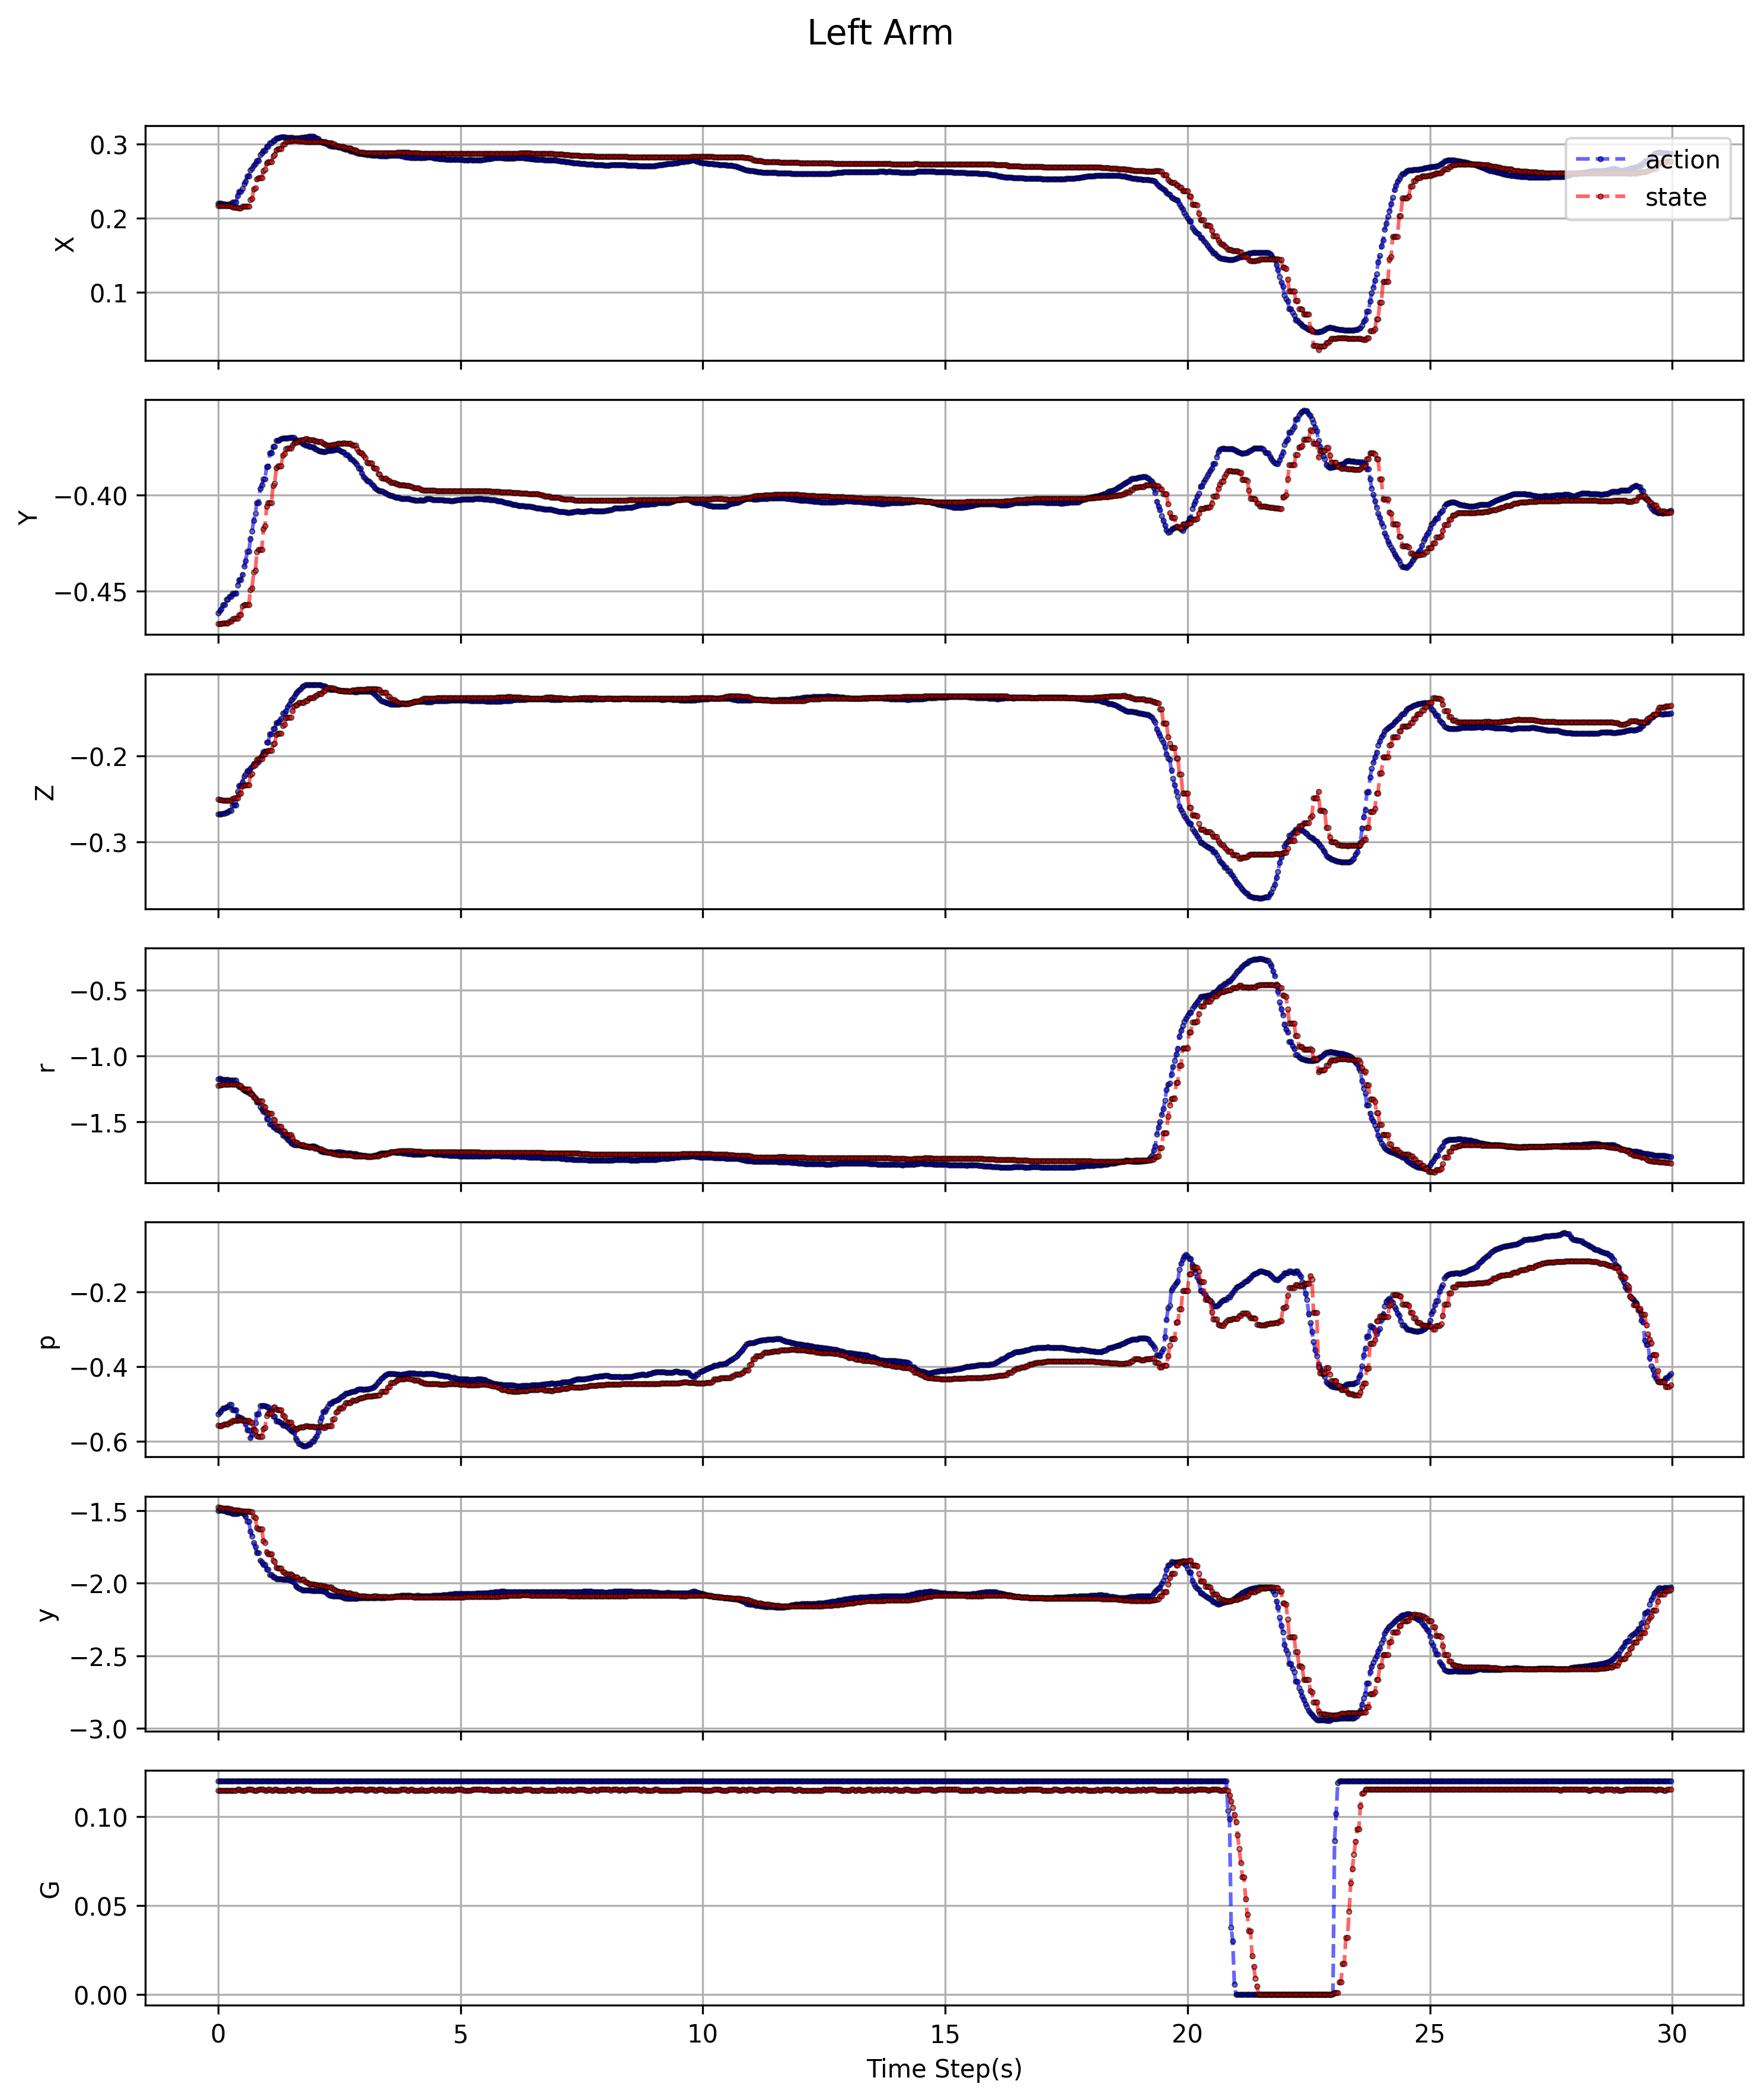

In [27]:
l_action_points = preprocess_rotvec(l_action_points)
l_state_points = preprocess_rotvec(l_state_points)
plot_variant_comparison(l_action_points, l_state_points, save_name = repo_id + '_' + str(episode_id))

In [20]:
torch.save(l_state_points[...,3:6], 'epi5_state.pt')